# Importing Libraries

In [79]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
from single_cell.preprocess import *

In [101]:
adata = sc.datasets.pbmc3k()
# sc.read_h5ad("data/pbmc3k_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [102]:
adata.layers["counts"] = adata.X.copy()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: 'counts'

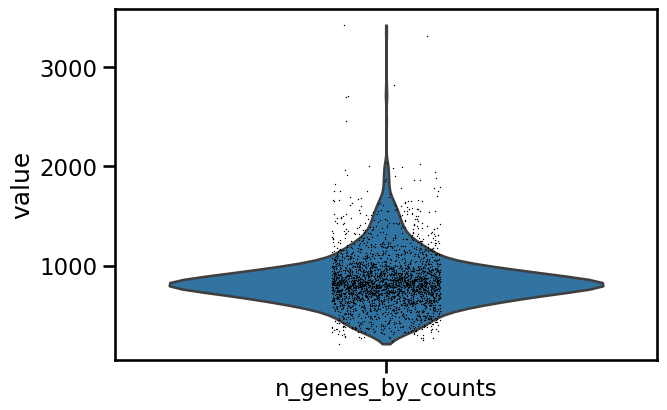

In [103]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=[20])
sc.pl.violin(adata, "n_genes_by_counts")

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts'
AnnData object with n_obs × n_vars = 2685 × 12572
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'n_genes'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'counts'


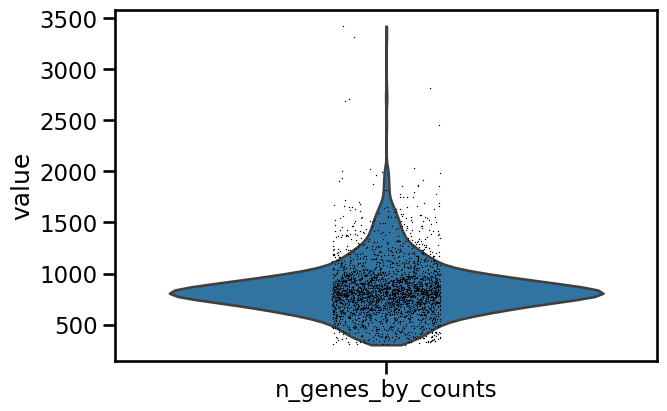

In [104]:
print(adata)
sc.pp.filter_genes(adata, min_cells=5)
sc.pp.filter_cells(adata, min_genes=300)
print(adata)
sc.pl.violin(adata, "n_genes_by_counts")

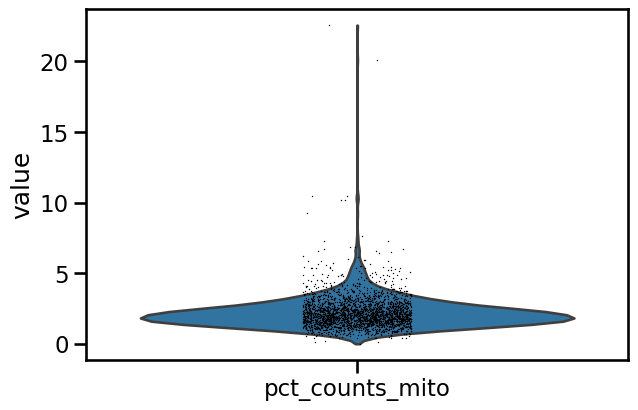

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,n_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
index,,,,,,,,,
AAACATACAACCAC-1,779,6.659294,2419.0,7.791523,28.234808,779,73.0,4.304065,3.017776
AAACATTGAGCTAC-1,1350,7.208600,4901.0,8.497398,26.157927,1350,186.0,5.231109,3.795144
AAACATTGATCAGC-1,1127,7.028201,3145.0,8.053887,27.917329,1127,28.0,3.367296,0.890302
AAACCGTGCTTCCG-1,958,6.865891,2637.0,7.877776,24.573379,958,46.0,3.850148,1.744406
AAACCGTGTATGCG-1,521,6.257668,980.0,6.888573,34.081633,521,12.0,2.564949,1.224490
...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1152,7.050123,3458.0,8.148735,24.262580,1152,73.0,4.304065,2.111047
TTTCTACTGAGGCA-1,1222,7.109062,3441.0,8.143808,23.132810,1222,32.0,3.496508,0.929962
TTTCTACTTCCTCG-1,621,6.432940,1683.0,7.428927,27.748069,621,37.0,3.637586,2.198455


In [106]:
adata.var["mito"] = adata.var.index.str.contains("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars="mito", inplace=True, percent_top=[20], log1p=True
)
sc.pl.violin(adata, "pct_counts_mito")
adata.obs

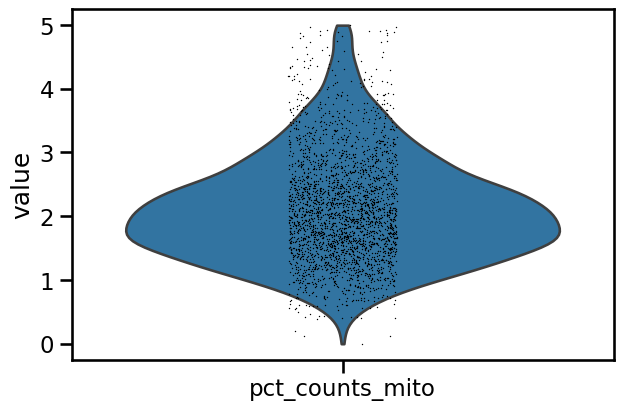

View of AnnData object with n_obs × n_vars = 2633 × 12572
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'n_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mito'
    layers: 'counts'

In [107]:
adata = adata[adata.obs["pct_counts_mito"] < 5]
sc.pl.violin(adata, "pct_counts_mito")
adata

In [108]:
adata.layers["normalized"] = adata.layers["counts"].copy()
sc.pp.normalize_total(adata, layer="normalized", target_sum=1e4)
sc.pp.log1p(adata, layer="normalized")

/tmp/ipykernel_2773394/2030592935.py:1: ImplicitModificationWarning: Setting element `.layers['normalized']` of view, initializing view as actual.
  adata.layers["normalized"] = adata.layers["counts"].copy()


In [ ]:
for method in ["doubletdetection", "scrublet", "scDblFinder", "DoubletFinder"]:
    Filter_Doublets(adata, method, remove=False)

# adata = adata[adata.obs["doubletdetection_predicted"] == True & adata.obs["scrublet_predicted"] == True]
# adata now has removed all doublets predicted by `doubletdetection` and `scrublet`

Finding HVGs...
Setting layer to normalized.
Starting PCA with gene mask highly_variable at 50 comps, saved at .obsm[PCA-hvg].


/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)



---------------------------------------------
begin neighbors & UMAP at Fri Jun 26 14:39:44 2026, (total: 1:15:36.880524)

Starting UMAP...


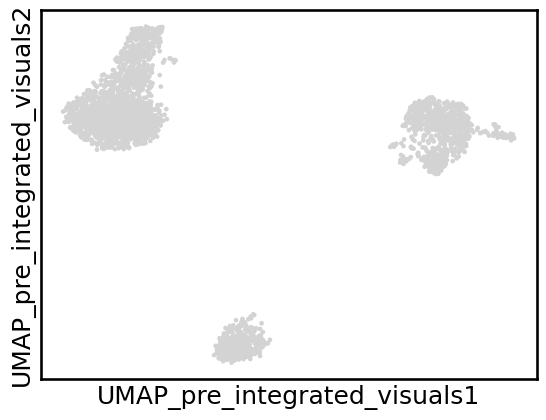

Running NN Backend on high-dimensional data. Nearest-neighbor search may be slow!


finished neighbors & UMAP in 0:00:18.981206


---------------------------------------------
begin LocalMAP at Fri Jun 26 14:40:03 2026, (total: 1:15:55.861989)



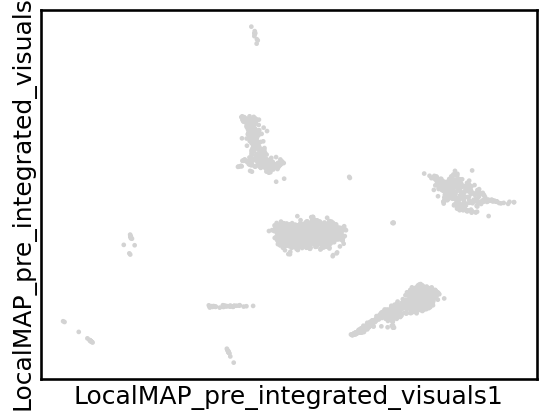

finished LocalMAP in 0:00:02.233840


---------------------------------------------
begin PaCMAP at Fri Jun 26 14:40:05 2026, (total: 1:15:58.095931)



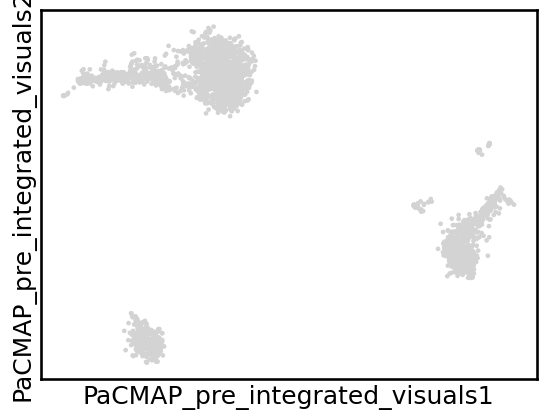

finished PaCMAP in 0:00:02.070581



AnnData object with n_obs × n_vars = 2633 × 12572
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'n_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mito', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'methods', 'hvg', 'PCA-hvg', 'neighbors_pre_integrated_visuals', 'UMAP_pre_integrated_visuals'
    obsm: 'PCA-hvg', 'UMAP_pre_integrated_visuals', 'LocalMAP_pre_integrated_visuals', 'PaCMAP_pre_integrated_visuals'
    varm: 'PCA-hvg'
    layers: 'counts', 'normalized'
    obsp: 'neighbors_pre_integrated_visuals_distances', 'neighbors_pre_integrated_visuals_connectivities'

In [ ]:
FindVariableGenes(adata, "seurat_v3", n_features=500)

# now, adata.var["highly_variable"] column exists

PCA(adata, "highly_variable", "PCA-hvg")

# now, adata.obsm["PCA-hvg"] has a 50 component PCA loading. The 50 component weights are in adata.varm["PCA-hvg"].

Visualize(adata, "pre_integrated_visuals", obsm="PCA-hvg", pacmap=True, localmap=True)

# adata.uns["pre_integrated_visuals_neighbors"] = {adata.obsp key & parameteres}
# adata.obsp["pre_integrated_visuals_neighbors_connectivities"] & adata.obsp["pre_integrated_visuals_neighbors_distances"]

# adata.obsm["pre_integrated_visuals_UMAP"] & adata.uns[...]
# adata.obsm["pre_integrated_visuals_PacMAP"] & adata.uns[...]
# adata.obsm["pre_integrated_visuals_LocalMAP"] & adata.uns[...]

In [ ]:
sc.pl.embeddings(adata, embedding="pre_integrated_visuals_UMAP", color="pct_counts_mito")